In [ ]:
%run /content/AIFFEL_final_project_peekabook/research/src/state/state_v1.ipynb

In [ ]:
!pip install -qU langgraph langchain langchain-core langchain-community langchain-openai langchain-google-genai langchain-naver langchain-chroma chromadb -q

In [ ]:
!pip install -q -U langchain-core langchain langchain-openai langchain-community

In [ ]:
from google.colab import userdata

In [ ]:
import os
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
# os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
os.environ["CLOVASTUDIO_API_KEY"] = userdata.get('CLOVASTUDIO_API_KEY')

/tmp/ipykernel_25230/538973550.py:16: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma
/tmp/ipykernel_25230/538973550.py:64: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


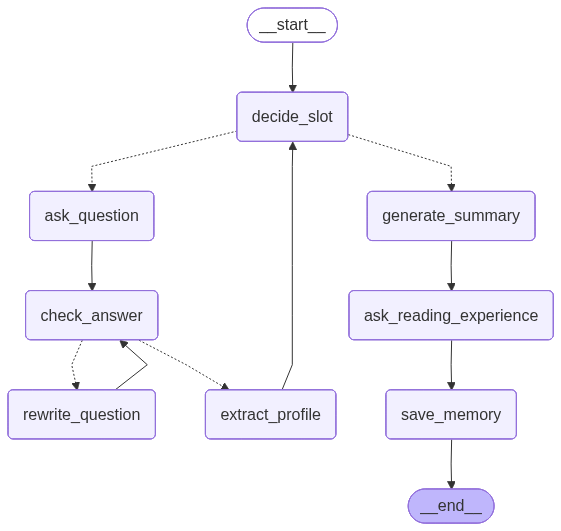

In [ ]:
from __future__ import annotations

from typing import TypedDict, Dict, Optional
from pydantic import BaseModel
from pathlib import Path
import json
import uuid

from langgraph.graph import StateGraph, END
from langgraph.types import interrupt

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_naver import ChatClovaX, ClovaXEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma

import json
import re


def safe_json_loads(text: str):

    text = text.strip()

    # ```json 제거
    text = re.sub(r"```json", "", text)
    text = re.sub(r"```", "", text)

    # JSON 부분만 추출
    match = re.search(r"\{.*\}", text, re.DOTALL)

    if not match:
        raise ValueError(f"JSON not found:\n{text}")

    json_text = match.group()

    json_text = json_text.replace("True", "true")
    json_text = json_text.replace("False", "false")

    return json.loads(json_text)

# ============================================================
# LLM
# ============================================================


#llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
# llm = ChatClovaX(model="HCX-005", temperature=0) # thinking =

# ============================================================
# ChromaDB
# ============================================================

DB_PATH = "./chroma_user_profile"

Path(DB_PATH).mkdir(parents=True, exist_ok=True)

# embedding_model = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
# embedding_model = ClovaXEmbeddings(model="bge-m3")

vectorstore = Chroma(
    collection_name="user_profile_memory",
    embedding_function=embedding_model,
    persist_directory=DB_PATH,
)

def extract_text_content(content):

    # 일반 문자열인 경우
    if isinstance(content, str):
        return content

    # content block list인 경우
    if isinstance(content, list):

        texts = []

        for item in content:

            if isinstance(item, dict):

                if item.get("type") == "text":
                    texts.append(item.get("text", ""))

        return "\n".join(texts)

    return str(content)
# ============================================================
# Profiling Schema
# ============================================================

PROFILE_SCHEMA = {
    "reading_goal": "현재 독서 목적",
    "preferred_genre": "현재 관심 있는 장르 및 분야",
    "reading_style": "선호 독서 스타일",
    "difficulty_level": "선호 난이도",
    "current_context": "언제, 어떤 감정이나 상황에서 읽고자 하는지",
}

PROFILE_ORDER = list(PROFILE_SCHEMA.keys())


# ============================================================
# State
# ============================================================

# class CRSState(TypedDict):

#     profile: Dict

#     current_slot: Optional[str]

#     current_question: Optional[str]

#     last_user_answer: Optional[str]

#     answer_sufficient: bool

#     summary: Optional[str]

#     reading_experience: Optional[str]

#     finished: bool


# ============================================================
# Utils
# ============================================================

def get_unfilled_slot(profile):

    for slot in PROFILE_ORDER:
        if slot not in profile:
            return slot

    return None


# ============================================================
# Node 1. Decide Slot
# ============================================================

def decide_slot_node(state: CRSState):

    next_slot = get_unfilled_slot(state["profile"])

    if next_slot is None:
        state["finished"] = True
        state["current_slot"] = None
    else:
        state["finished"] = False
        state["current_slot"] = next_slot

    return state


# ============================================================
# Node 2. Ask Question
# ============================================================

def ask_question_node(state: CRSState):

    slot = state["current_slot"]

    description = PROFILE_SCHEMA[slot]

    prompt = f"""
당신은 AI 도서 큐레이션 시스템의 사용자 프로파일링 전문가이다.

현재 추출할 정보:
- {slot}
- 설명: {description}

조건:
- 반드시 현재의 생각을 묻는 질문 생성
- 사용자가 자연스럽게 답변할 수 있는 질문 생성
- 한 번에 하나만 질문
- 현재 대화 흐름 고려

중요 규칙:
- 질문 외의 설명 금지
- 안내 문구 금지
- 인사말 금지

"""

    response = llm.invoke(prompt)

    #question = response.content
    question = extract_text_content(response.content)

    state["current_question"] = question

    # ========================================================
    # 사용자 입력 대기
    # ========================================================

    user_answer = interrupt(question)

    state["last_user_answer"] = user_answer

    return state


# ============================================================
# Node 3. Check Sufficiency
# ============================================================
class SufficiencyResult(BaseModel):
    sufficient: bool

def check_answer_node(state: CRSState):

    slot = state["current_slot"]

    answer = state["last_user_answer"]

    prompt = f"""
사용자의 답변이 도서 추천에 활용 가능할 정도로 충분한지 판단하라.

슬롯:
{slot}

사용자 답변:
{answer}

판단 기준:
- 도서 추천에 활용 가능한 수준인가?
- 의미가 충분히 구체적인가?
- 답변이 모호하거나 관련이 없는가?

반드시 아래 JSON 형식으로만 출력하라.

{{
    "sufficient": true
}}

또는

{{
    "sufficient": false
}}
"""
    #structured_llm = llm.with_structured_output(SufficiencyResult)
    #response = structured_llm.invoke(prompt)
    #state["answer_sufficient"] = response.sufficient

    #result = json.loads(response.content)

    #state["answer_sufficient"] = result["sufficient"]

    response = llm.invoke(prompt)

    text = extract_text_content(response.content)

    result = safe_json_loads(text)

    state["answer_sufficient"] = result["sufficient"]

    return state


# ============================================================
# Node 4. Rewrite Question
# ============================================================

def rewrite_question_node(state: CRSState):

    slot = state["current_slot"]

    answer = state["last_user_answer"]

    original_question = state["current_question"]

    prompt = f"""
사용자의 답변이 충분하지 않았다.

현재 슬롯:
{slot}

기존 질문:
{original_question}

사용자 답변:
{answer}

목표:
- 더 쉽게 이해되도록 질문 재작성
- 사용자가 구체적으로 답할 수 있게 유도
- 예시 포함 가능
- 질문 하나만 출력

중요 규칙:
- 질문 외의 설명 금지
- 안내 문구 금지
- 인사말 금지

"""

    response = llm.invoke(prompt)

    #rewritten_question = response.content
    rewritten_question = extract_text_content(response.content)

    # ========================================================
    # 다시 사용자 응답 대기
    # ========================================================

    new_answer = interrupt(rewritten_question)

    state["current_question"] = rewritten_question
    state["last_user_answer"] = new_answer

    return state


# ============================================================
# Node 5. Extract Profile
# ============================================================
class ExtractResult(BaseModel):
    value: str

def extract_profile_node(state: CRSState):

    slot = state["current_slot"]
    description = PROFILE_SCHEMA[slot]

    answer = state["last_user_answer"]

    prompt = f"""
사용자 답변에서 핵심 선호 정보를 추출하라.

슬롯:
{slot}

슬롯 설명:
{description}

사용자 답변:
{answer}

목표:
- 추천에 활용 가능한 구체적인 핵심 정보를 추출
- 너무 장황하지 않게 정리

반드시 아래 JSON 형식으로만 출력하라.

{{
    "value": "추출 결과"
}}

"""

    #extract_llm = llm.with_structured_output(ExtractResult)
    #response = extract_llm.invoke(prompt)

    #result = json.loads(response.content)

    #state["profile"][slot] = result["value"]
    #state["profile"][slot] = response.value

    response = llm.invoke(prompt)

    text = extract_text_content(response.content)

    result = safe_json_loads(text)

    state["profile"][slot] = result["value"]

    return state


# ============================================================
# Node 6. Generate Summary
# ============================================================

def generate_summary_node(state: CRSState):

    profile = state["profile"]

    prompt = f"""
당신은 사용자 프로파일 정보를 정리하는 시스템이다.

다음 사용자 프로파일 정보를 기반으로 사용자의 현재 독서 성향과 상황을 간결하게 요약하라.

프로필:
{json.dumps(profile, ensure_ascii=False, indent=2)}

조건:
- 3~5문장
- 도서 추천은 하지 말 것
- 현재 사용자의 취향, 상황, 목적을 포함할 것
"""

    response = llm.invoke(prompt)

    #state["summary"] = response.content
    state["summary"] = extract_text_content(response.content)

    return state


# ============================================================
# Node 7. Ask Reading Experience
# ============================================================

def ask_reading_experience_node(state: CRSState):

    summary = state["summary"]

    prompt = f"""
현재 사용자 상태:
{summary}

이전에 이와 유사한 맥락으로 책을 읽은 적 있는지, 읽었다면 책 제목과 책에 대한 감상이나 소감을 자연스럽게 물어보는 질문을 간략히 생성.

반드시 질문만 출력.
"""


    response = llm.invoke(prompt)

    #question = response.content
    question = extract_text_content(response.content)
    state["current_question"] = question

    user_answer = interrupt(question)

    state["reading_experience"] = user_answer

    return state


# ============================================================
# Node 8. Save Memory
# ============================================================

def save_memory_node(state: CRSState):

    memory = {
        "profile": state["profile"],
        "summary": state["summary"],
        "reading_experience": state["reading_experience"],
    }

    doc = Document(
        page_content=json.dumps(memory, ensure_ascii=False),
        metadata={
            "type": "user_profile",
            "user_id": "demo_user",
            "memory_id": str(uuid.uuid4()),
        }
    )

    vectorstore.add_documents([doc])

    return state


# ============================================================
# Router
# ============================================================

def sufficiency_router(state: CRSState):

    if state["answer_sufficient"]:
        return "extract_profile"

    return "rewrite_question"


def profiling_router(state: CRSState):

    if state["finished"]:
        return "generate_summary"

    return "ask_question"


# ============================================================
# Build Graph
# ============================================================

# graph = StateGraph(CRSState)

# graph.add_node("decide_slot", decide_slot_node)
# graph.add_node("ask_question", ask_question_node)
# graph.add_node("check_answer", check_answer_node)
# graph.add_node("rewrite_question", rewrite_question_node)
# graph.add_node("extract_profile", extract_profile_node)
# graph.add_node("generate_summary", generate_summary_node)
# graph.add_node("ask_reading_experience", ask_reading_experience_node)
# graph.add_node("save_memory", save_memory_node)

# graph.set_entry_point("decide_slot")

# graph.add_conditional_edges(
#     "decide_slot",
#     profiling_router,
#     {
#         "ask_question": "ask_question",
#         "generate_summary": "generate_summary",
#     }
# )

# graph.add_edge("ask_question", "check_answer")

# graph.add_conditional_edges(
#     "check_answer",
#     sufficiency_router,
#     {
#         "extract_profile": "extract_profile",
#         "rewrite_question": "rewrite_question",
#     }
# )

# graph.add_edge("rewrite_question", "check_answer")

# graph.add_edge("extract_profile", "decide_slot")

# graph.add_edge("generate_summary", "ask_reading_experience")

# graph.add_edge("ask_reading_experience", "save_memory")

# graph.add_edge("save_memory", END)

# app = graph.compile()

# app

In [ ]:
# from langgraph.checkpoint.memory import MemorySaver

# memory = MemorySaver()

# app = graph.compile(
#     checkpointer=memory
# )

In [ ]:
# from langgraph.types import Command

# # ============================================================
# # 초기 상태
# # ============================================================

# initial_state = {
#     "profile": {},
#     "current_slot": None,
#     "current_question": None,
#     "last_user_answer": None,
#     "answer_sufficient": False,
#     "summary": None,
#     "reading_experience": None,
#     "finished": False,
# }

# # ============================================================
# # thread_id
# # 사용자별 conversation memory 유지용
# # ============================================================

# config = {
#     "configurable": {
#         "thread_id": "user_001"
#     }
# }

# # ============================================================
# # 최초 graph 실행
# # ============================================================

# result = app.invoke(initial_state, config=config)

# # ============================================================
# # Multi-turn Loop
# # ============================================================

# while True:

#     # --------------------------------------------------------
#     # interrupt 발생 여부 확인
#     # --------------------------------------------------------

#     if "__interrupt__" in result:

#         interrupt_obj = result["__interrupt__"][0]

#         question = interrupt_obj.value

#         print(f"\nAI: {question}")

#         # ----------------------------------------------------
#         # 사용자 입력
#         # ----------------------------------------------------

#         user_input = input("\nUSER: ")

#         # ----------------------------------------------------
#         # graph resume
#         # ----------------------------------------------------

#         result = app.invoke(
#             Command(resume=user_input),
#             config=config
#         )

#     else:

#         # ----------------------------------------------------
#         # 종료
#         # ----------------------------------------------------

#         print("\n=== USER PROFILING FINISHED ===\n")

#         print("PROFILE:")
#         print(
#             json.dumps(
#                 result["profile"],
#                 ensure_ascii=False,
#                 indent=2
#             )
#         )

#         print("\nSUMMARY:")
#         print(result["summary"])

#         break


AI: 요즘 독서를 통해 무엇을 얻고 싶으신가요? 예를 들어, 지식을 넓히고 싶다거나 스트레스를 해소하고 싶은 등 다양한 목적이 있을 텐데요, 구체적으로 어떤 목표를 가지고 계신지 궁금합니다. 

USER: 철학책을 공부하고 싶어

AI: 요즘 어떤 장르나 분야의 책에 가장 관심이 가시나요? 

USER: 실존주의 철학

AI: 평소에 책을 읽을 때, 어떤 방식으로 읽는 것을 가장 즐기시나요? 예를 들어, 깊이 있는 분석과 비평을 중시하는 편인가요, 아니면 이야기 자체의 흥미와 재미를 더 중요하게 생각하시나요? 

USER: 깊이 있는 분석을 중시해

AI: 어떤 책을 읽을 때 가장 몰입하고 즐겁게 읽으시나요? 너무 쉽거나 어려운 책보다는 적당한 난이도의 책이 좋으신가요, 아니면 도전적인 책을 선호하시나요? 

USER: 의미있는 삶을 알려주는 책을 몰입해서 읽는 편이야. 그리고 도전적인 수준의 책을 좋아해

AI: 지금 이 순간, 특별히 어떤 감정이나 상황을 느끼며 책을 읽고 싶으신가요? 예를 들어, 스트레스를 풀고 싶다거나 새로운 지식을 얻고 싶은 등의 이유가 있을 수 있습니다. 자신의 감정을 솔직하게 말씀해 주시면 적합한 도서를 추천하는 데 도움이 될 것입니다.

USER: 조용히, 혼자만의 상황에서 책을 읽고 싶어

AI: 혹시 이전에 실존주의 철학 관련 도서를 읽어보신 경험이 있으신가요? 만약 그렇다면, 그 책의 제목은 무엇이었으며, 해당 책을 읽고 어떤 감상을 하셨는지 궁금합니다. 특히, 자아의 의미나 삶의 목적에 대해 어떻게 생각하게 되셨는지 공유해주실 수 있을까요?

USER: 아니. 읽어본 적 없어

=== USER PROFILING FINISHED ===

PROFILE:
{
  "reading_goal": "철학책",
  "preferred_genre": "실존주의 철학",
  "reading_style": "깊이 있는 분석",
  "difficulty_level": "몰입, 도전적 수준 책 선호",
  "current_context": 

In [ ]:
# data = vectorstore.get()

In [ ]:
# data